# LED Wall — Composed Scenes

Multiple plugins composited into a single frame using `Renderer`.

In [1]:
%matplotlib inline

In [2]:
from ledwall_server.plugins.bitcoin import Bitcoin
from ledwall_server.plugins.clock import Clock
from ledwall_server.plugins.text import ScrollingText, StaticText
from ledwall_server.plugins.weather import Weather
from ledwall_server.renderer import Renderer
from picow_ws2812_devtools.visualizer import LedWallVisualizer

## Scene Snapshot

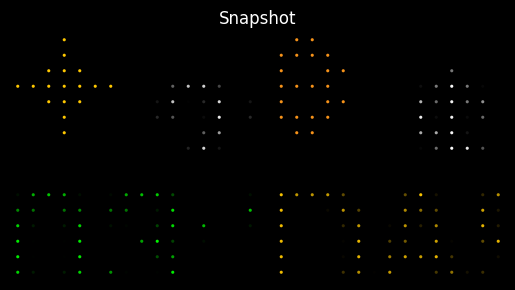

In [3]:
scene_w, scene_h = 32, 16
renderer = Renderer(scene_w, scene_h)

weather_dash = Weather({"screen_mode": "fixed"}, 16, 8)
weather_dash._temp = "22"
weather_dash._humidity = "65"
weather_dash._weather_code = 0
weather_dash._fetched = True
weather_dash.screen_manager.screens = weather_dash._build_screens()

btc_dash = Bitcoin({"screen_mode": "fixed"}, 16, 8)
btc_dash._price = 97200.0
btc_dash._trends = {"24h": 2.3, "48h": -1.5, "7d": 5.2, "1m": 12.1}
btc_dash._fetched = True
btc_dash.screen_manager.screens = btc_dash._build_screens()

layers = [
    (weather_dash, 0, 0),
    (btc_dash, 16, 0),
    (Clock({"color": [0, 255, 0]}, 16, 8), 0, 8),
    (StaticText({"text": "DASH", "color": [255, 200, 0]}, 16, 8), 16, 8),
]

scene_viz = LedWallVisualizer(width=scene_w, height=scene_h, dot_radius=0.1)
scene_viz.snapshot(renderer=renderer, layers=layers)

## Animated Scene

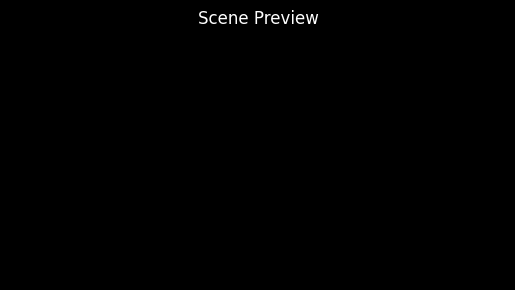

In [4]:
scene_w, scene_h = 32, 16
renderer = Renderer(scene_w, scene_h)

weather_live = Weather({"screen_mode": "auto", "screen_interval": 60}, 16, 8)
weather_live._temp = "22"
weather_live._humidity = "65"
weather_live._weather_code = 0
weather_live._fetched = True
weather_live.screen_manager.screens = weather_live._build_screens()

btc_live = Bitcoin({"screen_mode": "auto", "screen_interval": 60}, 16, 8)
btc_live._price = 97200.0
btc_live._trends = {"24h": 2.3, "48h": -1.5, "7d": 5.2, "1m": 12.1}
btc_live._fetched = True
btc_live.screen_manager.screens = btc_live._build_screens()

layers = [
    (weather_live, 0, 0),
    (btc_live, 16, 0),
    (ScrollingText({"text": "LED WALL", "color": [255, 200, 0]}, 16, 8), 16, 8),
]

scene_viz = LedWallVisualizer(width=scene_w, height=scene_h, dot_radius=0.1)
scene_viz.preview_scene(renderer, layers, frames=400)